# Experiment: Effect of Photometric Redshift **Bias** on the LSST Y10 PDSPL Sample

Notebook `05b` degrades the photo-$z$ *precision*.  Because the same $\sigma_z$ is used to build
the Asimov data and to model it, the contours widen but stay centred on the truth.  This notebook
instead introduces an unrecognised photo-$z$ **bias**: the mock $\beta_E$ values are generated at
the true redshifts, while the inference is handed *shifted* redshifts.  Any displacement of the
posterior is therefore a pure accuracy effect.

A bias $\Delta z = b\,(1+z)$ enters at two stages:

1. **Pairing.** Only $z_D$ is a pairing feature, and it enters through $\Delta z_D / z_D$ between
   two *matched* deflectors.  A smooth multiplicative bias is common-mode and largely cancels.
   Section 1 measures this rather than assuming it.
2. **Inference.** The assumed $(z_D, z_{S1}, z_{S2})$ set the model $\beta$, so a bias moves the
   posterior. Section 2 measures the displacement.

Deflector and source photo-$z$ biases are treated separately: deflectors are bright red-sequence
ellipticals, whereas the lensed sources are faint and blended with the deflector light, so their
systematics are independent and the source bias is expected to dominate.

In [1]:
import os
import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM
from tqdm import tqdm

from pdspl_utils.data_utils import preprocess_ggl_table
from pdspl_utils.pairing import (
    get_kdtree_pairs,
    get_pairs_table_PDSPL,
    inject_observational_errors,
    compute_dissimilarity,
    eval_scatter_model,
    plot_beta_E_vs_D_MC,
)
from pdspl_utils.inference import (
    draw_lens_from_given_zs,
    run_dspl_inference,
    beta_double_source_plane,
    beta2theta_e_ratio,
)
from pdspl_utils.plotting import plot_dspl_corner, plot_w0wa

warnings.filterwarnings("ignore")

POSTERIOR_DIRECTORY = "../data/posteriors/expt_photoz_bias"
FIGURE_DIRECTORY    = "../figures/forecasts/expt_photoz_bias"
SAMPLES_DIRECTORY   = "../data/samples"
for _d in (POSTERIOR_DIRECTORY, FIGURE_DIRECTORY, SAMPLES_DIRECTORY):
    os.makedirs(_d, exist_ok=True)

%load_ext autoreload
%autoreload 2

In [2]:
MASTER_SEED = 20260825
np.random.seed(MASTER_SEED)

cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)

GGL_table_LSST_Y10 = preprocess_ggl_table(
    "../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits"
)
print(f"LSST Y10 catalog: {len(GGL_table_LSST_Y10)} lenses")

LSST Y10 catalog: 116471 lenses


## 1. Does a photo-$z$ bias degrade the pairing?

Two pairing configurations, identical apart from a coherent offset added to the deflector
redshift on top of the fiducial $\sigma_z/(1+z) = 0.03$ scatter.

In [3]:
Z_D_BIAS_LEVELS = {
    "zD_unbiased":  0.00,
    "zD_bias_0.01": 0.01,
}

pdspl_samples_expt = {
    "zD_unbiased":  {"name": r"$\Delta z_D = 0$",             "color": "#009E73"},
    "zD_bias_0.01": {"name": r"$\Delta z_D = +0.01(1+z_D)$",  "color": "#D55E00"},
}

pairing_keys = ["z_D", "R_e_arcsec", "flux_D_i", "flux_ratio_D_gr", "flux_ratio_D_ri"]
dissim_keys  = ["rel_diff_z_D", "rel_diff_R_e_arcsec", "rel_diff_flux_D_i",
                "rel_diff_flux_ratio_D_gr", "rel_diff_flux_ratio_D_ri"]

# Identical to notebook 03; only the z_D bias differs between the two configurations.
error_config = {
    "sigma_v_D":       10.0,
    "z_D":             lambda t: 0.03  * (1 + t["z_D"]),
    "R_e_arcsec":      lambda t: 0.05  * t["R_e_arcsec"],
    "flux_D_i":        lambda t: 0.01  * t["flux_D_i"],
    "flux_ratio_D_gr": lambda t: 0.014 * t["flux_ratio_D_gr"],
    "flux_ratio_D_ri": lambda t: 0.014 * t["flux_ratio_D_ri"],
}

for key, s in pdspl_samples_expt.items():
    s["table"]              = GGL_table_LSST_Y10
    s["pairing_keys"]       = pairing_keys
    s["dissimilarity_keys"] = dissim_keys
    s["error_config"]       = error_config
    s["z_D_bias"]           = Z_D_BIAS_LEVELS[key]


def inject_errors_with_bias(table, error_config, z_D_bias):
    """Gaussian scatter plus a coherent offset b(1+z) on the true deflector redshift."""
    noisy = inject_observational_errors(table, error_config)
    if z_D_bias:
        noisy["z_D"] = noisy["z_D"] + z_D_bias * (1 + np.asarray(table["z_D"], float))
    return noisy

In [4]:
N_realizations    = 500
METRIC            = "rms"
MAX_DISSIMILARITY = 0.15

mc_results_expt = {
    k: {"binned_dissim": [], "binned_scatter": [], "num_pairs": [], "scatter_in_beta_E": []}
    for k in pdspl_samples_expt
}

for _ in tqdm(range(N_realizations), desc="MC Realizations"):
    for sample_key, s in pdspl_samples_expt.items():
        table_err = inject_errors_with_bias(s["table"], s["error_config"], s["z_D_bias"])

        indices, _ = get_kdtree_pairs(table_err, s["pairing_keys"], use_log_metric=True)

        pairs_table     = get_pairs_table_PDSPL(s["table"], indices, cosmo_true)
        pairs_table_err = get_pairs_table_PDSPL(table_err,  indices, cosmo_true)
        pairs_table_err["dissimilarity"] = compute_dissimilarity(
            pairs_table_err, s["dissimilarity_keys"], method=METRIC
        )

        s["pairs_analysis"] = {
            "pairs_table":             pairs_table,
            "pairs_table_with_errors": pairs_table_err,
            "num_lenses":              len(s["table"]),
            "num_pairs":               len(pairs_table),
            "scatter_in_beta_E":       np.std(pairs_table["rel_diff_beta_E"]),
            "pair_indices":            indices,
        }

        mc_results_expt[sample_key]["num_pairs"].append(len(pairs_table))
        mc_results_expt[sample_key]["scatter_in_beta_E"].append(
            np.std(pairs_table["rel_diff_beta_E"])
        )

        mask = (pairs_table_err["dissimilarity"] < MAX_DISSIMILARITY) & \
               np.isfinite(pairs_table["rel_diff_beta_E"])
        dissim_masked = pairs_table_err["dissimilarity"][mask]
        delta_masked  = pairs_table["rel_diff_beta_E"][mask]

        percentiles = np.percentile(dissim_masked, np.arange(0, 101, 10))
        digitized   = np.digitize(dissim_masked, percentiles)

        run_dissim, run_scatter = [], []
        for i in range(1, len(percentiles)):
            bm = digitized == i
            run_dissim.append(np.median(dissim_masked[bm]) if np.any(bm) else np.nan)
            run_scatter.append(np.nanstd(delta_masked[bm]) if np.any(bm) else np.nan)

        mc_results_expt[sample_key]["binned_dissim"].append(run_dissim)
        mc_results_expt[sample_key]["binned_scatter"].append(run_scatter)

for sample_key, s in pdspl_samples_expt.items():
    s["pairs_analysis"]["mean_num_pairs"] = np.nanmean(mc_results_expt[sample_key]["num_pairs"])
    s["pairs_analysis"]["mean_scatter_in_beta_E"] = np.nanmean(
        mc_results_expt[sample_key]["scatter_in_beta_E"]
    )

MC Realizations: 100%|██████████| 500/500 [09:10<00:00,  1.10s/it]


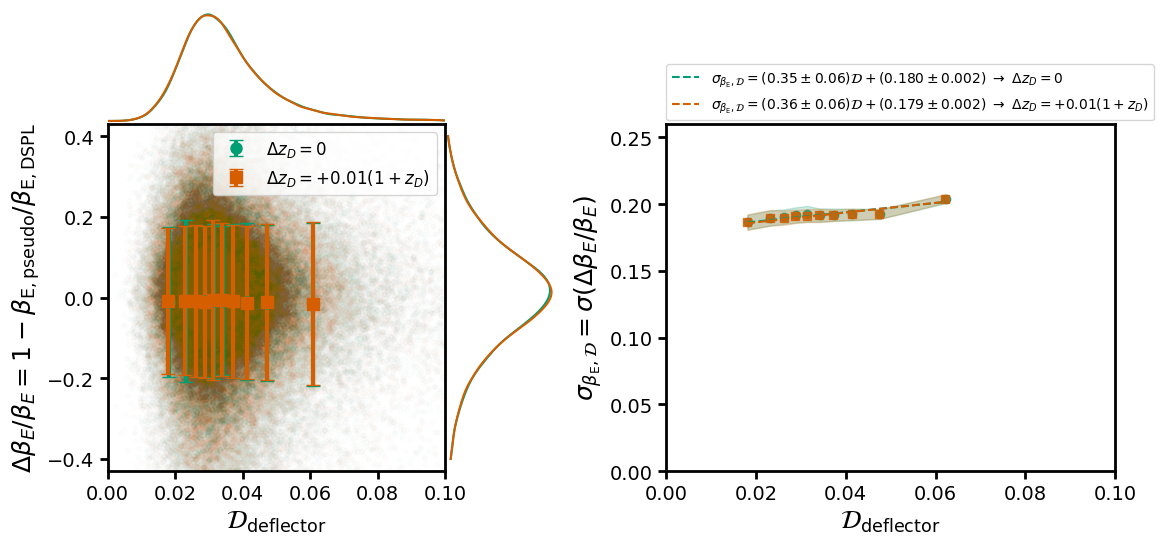


Pairing config | c0 (floor) | c1 (slope) |  <N_pairs> | sigma(beta_E)
--------------------------------------------------------------------
zD_unbiased    |     0.1800 |     0.3471 |      85823 |        0.1925
zD_bias_0.01   |     0.1790 |     0.3647 |      85829 |        0.1922

c0 ratio (biased / unbiased) = 0.9949


In [5]:
sample_colors  = {k: s["color"] for k, s in pdspl_samples_expt.items()}
sample_markers = {"zD_unbiased": "o", "zD_bias_0.01": "s"}

fig_beta_D = plot_beta_E_vs_D_MC(
    pdspl_samples_expt, mc_results_expt,
    fit_type="linear",
    show_fit_eqn_label=True,
    custom_colors_dict=sample_colors,
    custom_markers_dict=sample_markers,
    save_path=f"{FIGURE_DIRECTORY}/beta_E_vs_D_LSST_Y10_photoz_bias.png",
    legend_fontsize=10,
)
plt.show()

print(f"\n{'Pairing config':<14} | {'c0 (floor)':>10} | {'c1 (slope)':>10} | "
      f"{'<N_pairs>':>10} | {'sigma(beta_E)':>13}")
print("-" * 68)
for key, s in pdspl_samples_expt.items():
    pa = s["pairs_analysis"]
    c  = pa["scatter_vs_dissimilarity_fit_coeffs"]
    print(f"{key:<14} | {c[1]:>10.4f} | {c[0]:>10.4f} | "
          f"{pa['mean_num_pairs']:>10.0f} | {pa['mean_scatter_in_beta_E']:>13.4f}")

_ref = pdspl_samples_expt["zD_unbiased"]["pairs_analysis"]["scatter_vs_dissimilarity_fit_coeffs"]
_bia = pdspl_samples_expt["zD_bias_0.01"]["pairs_analysis"]["scatter_vs_dissimilarity_fit_coeffs"]
print(f"\nc0 ratio (biased / unbiased) = {_bia[1] / _ref[1]:.4f}")

## 2. Cosmological forecast under an unrecognised photo-$z$ bias

Each mock system carries $\beta_E$ evaluated at the **true** redshifts, while the likelihood is
given the **biased** redshifts and the fiducial $\sigma_z/(1+z) = 0.03$ error model — i.e. the
analyst is unaware of the offset.

In [6]:
truth = {
    "h0": 70.0, "om": 0.3, "w0": -1.0, "wa": 0.0,
    "lambda_int": 1.0, "lambda_sigma": 0.05,
    "gamma_pl":   2.078, "gamma_sigma": 0.16,
}
fixed_params = {"h0": 70.0}
cosmo_true_w = Flatw0waCDM(H0=truth["h0"], Om0=truth["om"], w0=truth["w0"], wa=truth["wa"])

# Kept identical to notebooks 04a / 05a / 05b so the contours are directly comparable.
N_TARGET_SYSTEMS   = 10000
SIGMA_MEAS_REL     = np.sqrt(0.01 ** 2 + 0.01 ** 2)
REDSHIFT_ERROR_REL = [0.03, 0.03, 0.03]

my_guess = {"om": 0.3, "w0": -1.0, "wa": 0.0, "lambda_int": 1.0,
            "lambda_sigma": 0.05, "gamma_pl": 2.078, "gamma_sigma": 0.16}
my_spreads = {"om": 0.1, "w0": 0.1, "wa": 0.1, "lambda_int": 0.1,
              "lambda_sigma": 0.01, "gamma_pl": 0.1, "gamma_sigma": 0.01}
my_priors = {
    "h0":           ("uniform", 50.0, 90.0),
    "om":           ("uniform",  0.0,  1.0),
    "w0":           ("uniform", -3.0,  0.0),
    "wa":           ("uniform", -5.0,  5.0),
    "lambda_int":   ("uniform",  0.8,  1.2),
    "lambda_sigma": ("uniform",  0.0,  0.2),
    "gamma_pl":     ("uniform",  1.0,  3.0),
    "gamma_sigma":  ("uniform",  0.0,  0.5),
}
MCMC_KWARGS = dict(n_walkers=64, n_steps=15000, n_burn=500)

In [7]:
# b_D, b_S are the coherent offsets Delta_z = b (1+z) applied to the deflector and to
# both source planes.  "pairing" selects the matching pairing configuration from Section 1.
scenarios = {
    "unbiased": {
        "name": r"No bias", "b_D": 0.0, "b_S": 0.0,
        "pairing": "zD_unbiased", "color": "#009E73",
    },
    "source_0.005": {
        "name": r"$\Delta z_S = +0.005(1+z)$", "b_D": 0.0, "b_S": 0.005,
        "pairing": "zD_unbiased", "color": "#0072B2",
    },
    "source_0.01": {
        "name": r"$\Delta z_S = +0.01(1+z)$", "b_D": 0.0, "b_S": 0.01,
        "pairing": "zD_unbiased", "color": "#CC79A7",
    },
    "coherent_0.01": {
        "name": r"$\Delta z_{D,S} = +0.01(1+z)$", "b_D": 0.01, "b_S": 0.01,
        "pairing": "zD_bias_0.01", "color": "#D55E00",
    },
}
for key, sc in scenarios.items():
    sc["backend_path"] = os.path.join(POSTERIOR_DIRECTORY, f"{key}.h5")

In [8]:
# One set of systems and one set of true-redshift Asimov data per pairing configuration.
rng = np.random.default_rng(MASTER_SEED + 1)
mock_base = {}

for pkey, s in pdspl_samples_expt.items():
    pa  = s["pairs_analysis"]
    pt  = pa["pairs_table"]
    dsf = len(pt) / N_TARGET_SYSTEMS
    idx = rng.choice(len(pt), size=N_TARGET_SYSTEMS, replace=False)

    z_D    = np.asarray(pt["z_D"][idx],  float)
    z_S1   = np.asarray(pt["z_S1"][idx], float)
    z_S2   = np.asarray(pt["z_S2"][idx], float)
    dissim = np.asarray(pa["pairs_table_with_errors"]["dissimilarity"][idx], float)

    coeffs   = pa["scatter_vs_dissimilarity_fit_coeffs"]
    fit_type = pa["scatter_vs_dissimilarity_fit_type"]

    kwargs_true = [
        draw_lens_from_given_zs(
            z_lens=z_D[j], z1=z_S1[j], z2=z_S2[j],
            lambda_mst_mean=truth["lambda_int"], lambda_mst_sigma=truth["lambda_sigma"],
            gamma_pl_mean=truth["gamma_pl"],     gamma_pl_sigma=truth["gamma_sigma"],
            sigma_beta_intrinsic=eval_scatter_model(coeffs, fit_type, dissim[j]),
            sigma_meas_rel=SIGMA_MEAS_REL,
            dissimilarity=dissim[j],
            down_sampling=dsf,
            with_noise=False,
            cosmo=cosmo_true_w,
            redshift_error_rel=REDSHIFT_ERROR_REL,
        )
        for j in tqdm(range(N_TARGET_SYSTEMS), desc=f"true-z mocks [{pkey}]")
    ]

    mock_base[pkey] = {
        "z_D": z_D, "z_S1": z_S1, "z_S2": z_S2, "dissim": dissim,
        "down_sampling": dsf, "coeffs": coeffs, "fit_type": fit_type,
        "kwargs_true": kwargs_true,
    }

true-z mocks [zD_bias_0.01]: 100%|██████████| 10000/10000 [00:07<00:00, 1351.69it/s]


In [9]:
# The biased mock: model-side quantities (redshifts, photo-z variance, beta derivatives) are
# evaluated at the assumed redshifts, while the data itself -- beta_E and its true generating
# variance -- is carried over from the true-redshift draw.
TRUTH_SIDE_KEYS = ["beta_dspl", "sigma_beta_dspl", "sigma_pop_true_sq"]

for key, sc in scenarios.items():
    base = mock_base[sc["pairing"]]
    sc.update({k: base[k] for k in ("down_sampling", "coeffs", "fit_type")})

    if sc["b_D"] == 0.0 and sc["b_S"] == 0.0:
        sc["kwargs_list"] = [dict(d) for d in base["kwargs_true"]]
        continue

    z_D_obs  = base["z_D"]  + sc["b_D"] * (1 + base["z_D"])
    z_S1_obs = base["z_S1"] + sc["b_S"] * (1 + base["z_S1"])
    z_S2_obs = base["z_S2"] + sc["b_S"] * (1 + base["z_S2"])

    kwargs_list = []
    for j, d_true in enumerate(tqdm(base["kwargs_true"], desc=f"biased mocks [{key}]")):
        d_obs = draw_lens_from_given_zs(
            z_lens=z_D_obs[j], z1=z_S1_obs[j], z2=z_S2_obs[j],
            lambda_mst_mean=truth["lambda_int"], lambda_mst_sigma=truth["lambda_sigma"],
            gamma_pl_mean=truth["gamma_pl"],     gamma_pl_sigma=truth["gamma_sigma"],
            sigma_beta_intrinsic=eval_scatter_model(
                sc["coeffs"], sc["fit_type"], base["dissim"][j]),
            sigma_meas_rel=SIGMA_MEAS_REL,
            dissimilarity=base["dissim"][j],
            down_sampling=sc["down_sampling"],
            with_noise=False,
            cosmo=cosmo_true_w,
            redshift_error_rel=REDSHIFT_ERROR_REL,
        )
        d_obs.update({k: d_true[k] for k in TRUTH_SIDE_KEYS})
        kwargs_list.append(d_obs)

    sc["kwargs_list"] = kwargs_list

biased mocks [coherent_0.01]: 100%|██████████| 10000/10000 [00:07<00:00, 1352.28it/s]


In [10]:
# Validation of the mock construction:
#   * the assumed geometry must stay physical -- beta2theta_e_ratio returns NaN for
#     z_S <= z_D, and a single NaN drives the whole log-likelihood to -inf;
#   * the unbiased control must be a self-consistent Asimov dataset, i.e. the data must
#     equal the model evaluated at the truth;
#   * the printed offset is the injected signal: the fractional data-model mismatch that
#     the sampler is forced to absorb by moving the parameters.
#
# beta_dspl is stored as a shape-(1,) array (the likelihood flattens it), so ravel before
# stacking -- otherwise the residual broadcasts to an (N, N) matrix.
for key, sc in scenarios.items():
    zl  = np.array([d["z_lens"]    for d in sc["kwargs_list"]], dtype=float)
    zs1 = np.array([d["z_source"]  for d in sc["kwargs_list"]], dtype=float)
    zs2 = np.array([d["z_source2"] for d in sc["kwargs_list"]], dtype=float)
    beta_obs = np.array(
        [np.ravel(d["beta_dspl"])[0] for d in sc["kwargs_list"]], dtype=float
    )

    mu = beta2theta_e_ratio(
        beta_double_source_plane(zl, zs1, zs2, cosmo_true_w),
        gamma_pl=truth["gamma_pl"], lambda_mst=truth["lambda_int"],
    )

    assert np.all((zl < zs1) & (zs1 < zs2)), f"unphysical assumed geometry in '{key}'"
    assert np.all(np.isfinite(mu)),          f"non-finite model values in '{key}'"
    if sc["b_D"] == 0.0 and sc["b_S"] == 0.0:
        assert np.allclose(beta_obs, mu), "unbiased control is not self-consistent"

    print(f"{key:<14} | mean fractional data-model offset at truth = "
          f"{np.mean((beta_obs - mu) / beta_obs):+.3e}")

unbiased       | mean fractional data-model offset at truth = -1.666e-07
source_0.005   | mean fractional data-model offset at truth = -2.798e-03
source_0.01    | mean fractional data-model offset at truth = -5.524e-03
coherent_0.01  | mean fractional data-model offset at truth = +1.190e-03


In [11]:
labels = None
for key, sc in scenarios.items():
    print(f"\nRunning: {sc['name']}")
    fixed_params_sc = fixed_params.copy()
    fixed_params_sc["beta_c0"] = sc["coeffs"][1]
    fixed_params_sc["beta_c1"] = sc["coeffs"][0]
    fixed_params_sc["beta_c2"] = 0.0

    sc["samples"], labels = run_dspl_inference(
        sc["kwargs_list"],
        initial_guess=my_guess,
        fixed_params=fixed_params_sc,
        initial_scatter=my_spreads,
        priors=my_priors,
        backend_path=sc["backend_path"],
        scatter_model_type=sc["fit_type"],
        **MCMC_KWARGS,
    )


Running: No bias
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 15000/15000 [38:35<00:00,  6.48it/s]



Running: $\Delta z_S = +0.005(1+z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 15000/15000 [38:17<00:00,  6.53it/s]



Running: $\Delta z_S = +0.01(1+z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 15000/15000 [38:21<00:00,  6.52it/s]



Running: $\Delta z_{D,S} = +0.01(1+z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 15000/15000 [39:41<00:00,  6.30it/s]


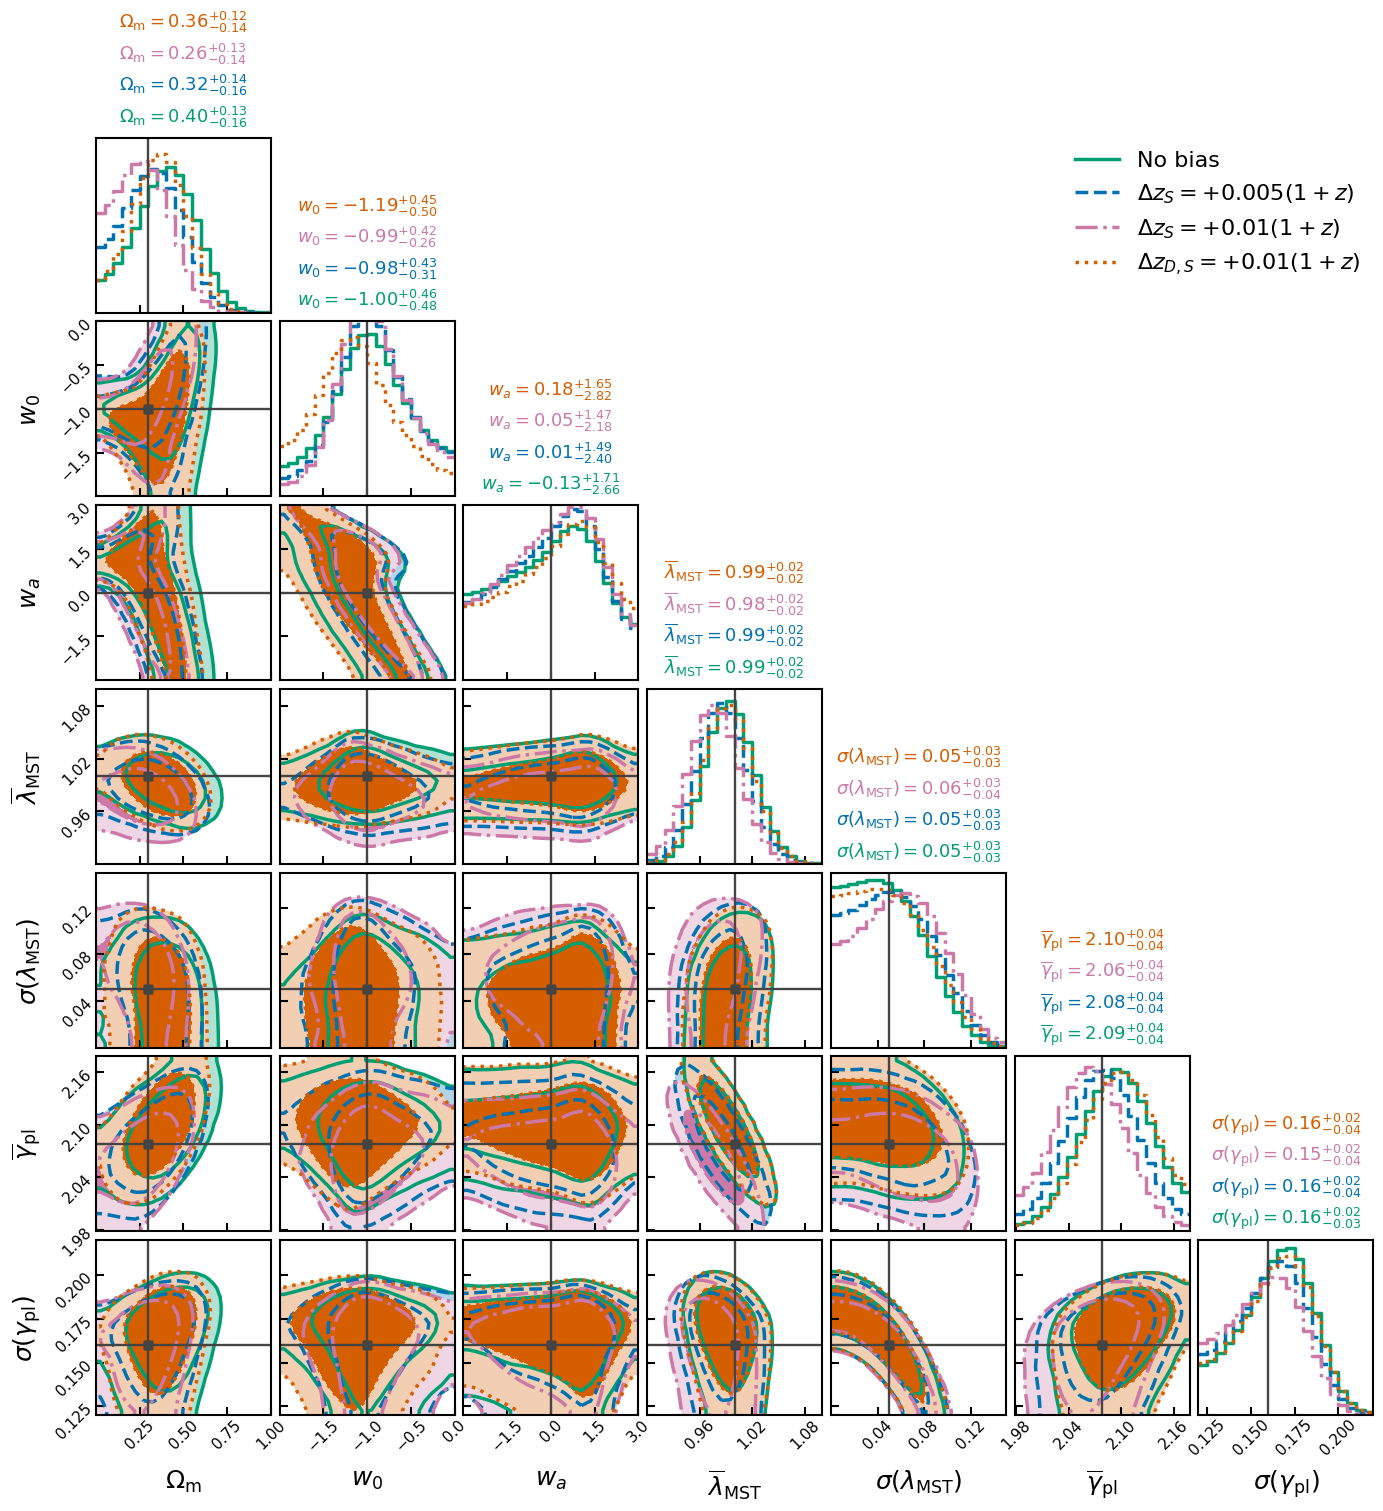

In [12]:
latex_labels = {
    "om":           r"$\Omega_{\rm m}$",
    "w0":           r"$w_0$",
    "wa":           r"$w_a$",
    "lambda_int":   r"$\overline{\lambda}_{\rm MST}$",
    "lambda_sigma": r"$\sigma({\lambda}_{\rm MST})$",
    "gamma_pl":     r"$\overline{\gamma}_{\rm pl}$",
    "gamma_sigma":  r"$\sigma({\gamma}_{\rm pl})$",
}
custom_ranges = [
    (0, 1), (-2, 0), (-3, 3),
    (truth["lambda_int"] - 0.1, truth["lambda_int"] + 0.1),
    (0.0, 0.15),
    (truth["gamma_pl"] - 0.1, truth["gamma_pl"] + 0.1),
    (0.12, 0.22),
]
plot_keys   = list(scenarios.keys())
plot_colors = {k: scenarios[k]["color"] for k in plot_keys}
plot_styles = {"unbiased": "-", "source_0.005": "--",
               "source_0.01": "-.", "coherent_0.01": ":"}

fig_corner = plot_dspl_corner(
    scenarios=scenarios, truth=truth, fixed_params=fixed_params,
    scenarios_to_plot=plot_keys,
    custom_ranges=custom_ranges, latex_labels=latex_labels, figsize=(14, 14),
    show_multiple_titles=True,
    custom_colors_dict=plot_colors,
    custom_linestyles_dict=plot_styles,
    save_path=os.path.join(FIGURE_DIRECTORY, "lsst_y10_photoz_bias_forecast_w0waCDM.pdf"),
)
plt.show()

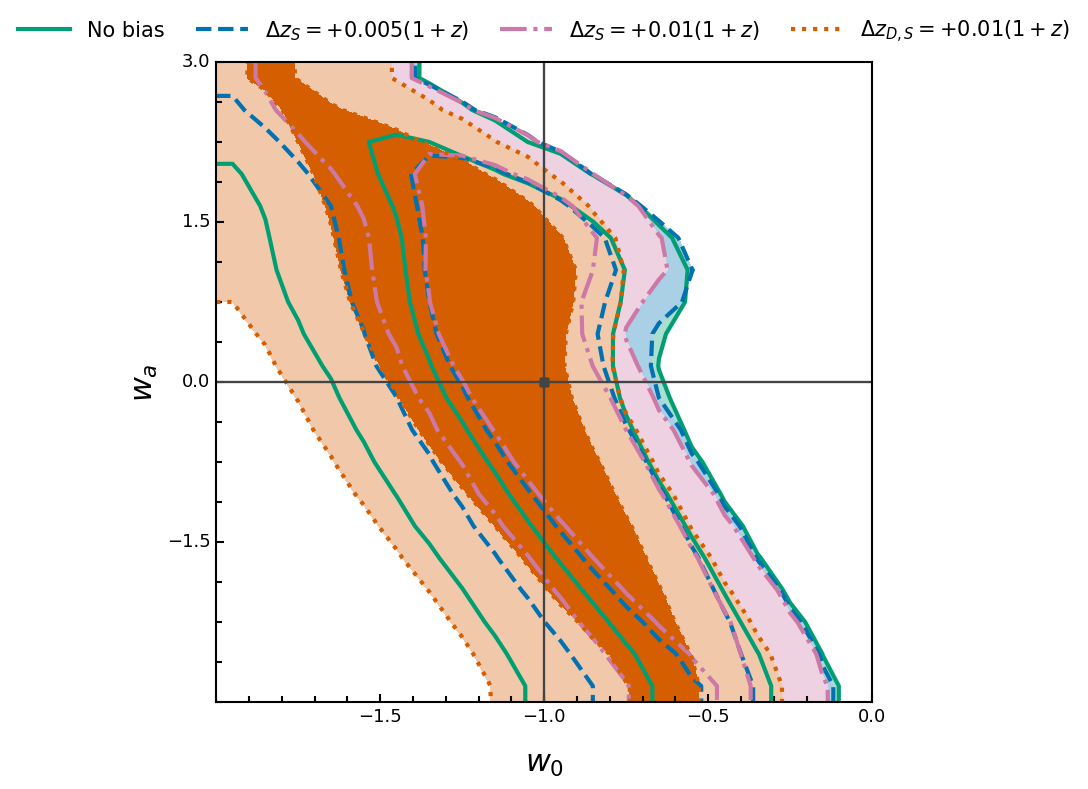

In [13]:
fig_w0wa, ax_w0wa = plot_w0wa(
    scenarios, truth, fixed_params,
    scenarios_to_plot=plot_keys,
    ranges=[custom_ranges[1], custom_ranges[2]],
    colors=plot_colors,
    linestyles=plot_styles,
    linewidths={k: 3.0 for k in plot_keys},
)
fig_w0wa.savefig(
    os.path.join(FIGURE_DIRECTORY, "lsst_y10_photoz_bias_w0wa.pdf"), bbox_inches="tight"
)
plt.show()

In [14]:
sampled_keys = [k for k in truth if k not in fixed_params]
i_w0, i_wa   = sampled_keys.index("w0"), sampled_keys.index("wa")

ref          = scenarios["unbiased"]["samples"]
ref_sigma    = {p: 0.5 * np.diff(np.percentile(ref[:, i], [16, 84]))[0]
                for i, p in enumerate(sampled_keys)}
ref_cov_inv  = np.linalg.inv(np.cov(ref[:, [i_w0, i_wa]], rowvar=False))


def w0wa_offset(samples):
    """(delta_w0, delta_wa) and its length in units of the unbiased 1-sigma error."""
    d = np.array([np.median(samples[:, i_w0]) - truth["w0"],
                  np.median(samples[:, i_wa]) - truth["wa"]])
    return d, np.sqrt(d @ ref_cov_inv @ d)


print("Shift of the posterior median from the truth, in units of the unbiased 1-sigma error\n")
print(f"{'Scenario':<28} | " + " | ".join(f"{p:>13}" for p in sampled_keys))
print("-" * (31 + 16 * len(sampled_keys)))
for key, sc in scenarios.items():
    row = [f"{(np.median(sc['samples'][:, i]) - truth[p]) / ref_sigma[p]:>+13.2f}"
           for i, p in enumerate(sampled_keys)]
    print(f"{sc['name']:<28} | " + " | ".join(row))

print(f"\n\nDisplacement in the (w0, wa) plane\n")
print(f"{'Scenario':<28} | {'d(w0)':>9} | {'d(wa)':>9} | {'N sigma':>9}")
print("-" * 62)
for key, sc in scenarios.items():
    d, n_sigma = w0wa_offset(sc["samples"])
    print(f"{sc['name']:<28} | {d[0]:>+9.3f} | {d[1]:>+9.3f} | {n_sigma:>9.2f}")

Shift of the posterior median from the truth, in units of the unbiased 1-sigma error

Scenario                     |            om |            w0 |            wa |    lambda_int |  lambda_sigma |      gamma_pl |   gamma_sigma
-----------------------------------------------------------------------------------------------------------------------------------------------
No bias                      |         +0.71 |         -0.00 |         -0.06 |         -0.32 |         -0.15 |         +0.46 |         +0.14
$\Delta z_S = +0.005(1+z)$   |         +0.15 |         +0.04 |         +0.01 |         -0.75 |         +0.07 |         +0.01 |         -0.07
$\Delta z_S = +0.01(1+z)$    |         -0.27 |         +0.03 |         +0.02 |         -1.22 |         +0.31 |         -0.40 |         -0.32
$\Delta z_{D,S} = +0.01(1+z)$ |         +0.43 |         -0.40 |         +0.08 |         -0.41 |         -0.07 |         +0.56 |         +0.10


Displacement in the (w0, wa) plane

Scenario                  

In [15]:
# Requirement on the spectroscopic calibration sample.  The displacement is linear in the
# offset for small b, so the scaling is fitted through the origin on the source-bias scan
# and inverted at a chosen tolerance.
BIAS_TOLERANCE = 0.3   # systematic shift below 30% of the statistical error

b_scan = np.array([scenarios[k]["b_S"] for k in ("source_0.005", "source_0.01")])
n_scan = np.array([w0wa_offset(scenarios[k]["samples"])[1]
                   for k in ("source_0.005", "source_0.01")])

slope = np.sum(b_scan * n_scan) / np.sum(b_scan ** 2)
b_max = BIAS_TOLERANCE / slope

print(f"Displacement scaling : {slope:.1f} sigma per unit Delta_z/(1+z)")
print(f"Linearity check      : {n_scan[1] / n_scan[0]:.2f} (2.00 if exactly linear)")
print(f"\nTo keep the (w0, wa) bias below {BIAS_TOLERANCE:.0%} of the statistical error,")
print(f"the residual source photo-z offset must satisfy  |Delta_z| / (1+z) < {b_max:.5f}")

Displacement scaling : 7.7 sigma per unit Delta_z/(1+z)
Linearity check      : 1.00 (2.00 if exactly linear)

To keep the (w0, wa) bias below 30% of the statistical error,
the residual source photo-z offset must satisfy  |Delta_z| / (1+z) < 0.03894


In [16]:
with open(f"{SAMPLES_DIRECTORY}/mc_results_photoz_bias.pkl", "wb") as f:
    pickle.dump(mc_results_expt, f)

# error_config holds lambdas and cannot be pickled
with open(f"{SAMPLES_DIRECTORY}/pdspl_samples_expt_photoz_bias.pkl", "wb") as f:
    pickle.dump(
        {k: {kk: vv for kk, vv in s.items() if kk != "error_config"}
         for k, s in pdspl_samples_expt.items()}, f
    )

with open(f"{SAMPLES_DIRECTORY}/forecast_scenarios_photoz_bias.pkl", "wb") as f:
    pickle.dump(
        {k: {kk: vv for kk, vv in sc.items() if kk != "kwargs_list"}
         for k, sc in scenarios.items()}, f
    )

print(f"Posteriors : {POSTERIOR_DIRECTORY}")
print(f"Figures    : {FIGURE_DIRECTORY}")
print(f"Summaries  : {SAMPLES_DIRECTORY}")

Posteriors : ../data/posteriors/expt_photoz_bias
Figures    : ../figures/forecasts/expt_photoz_bias
Summaries  : ../data/samples
